# 06 - SHAP Feature Importance Analysis

Applies SHAP (SHapley Additive exPlanations) to all trained classifiers to determine
which features drive spurious halo classification, and whether the importance ranking
shifts as the test distribution moves further from training.

**Scientific question:** is sphericity the most informative feature, or do formation
time, spatial clustering, or kinematic properties carry independent signal?

**Structure:**
1. Global importance: RF beeswarm (within-simulation, saved to `reports/figures/`)
2. Feature importance across all models (within-simulation)
3. Feature importance across splits (RF)
4. Dependence plots for key features
5. Host vs. subhalo breakdown
6. Scientific interpretation

## SHAP background

SHAP assigns each feature a contribution to a single prediction, defined as the average marginal contribution of that feature across all possible subsets of features.

The contributions sum to the difference between the model output and the expected output over the background dataset.

### Model-specific explainers used here

| Model | Explainer | Notes |
|---|---|---|
| RF, GBM | `TreeExplainer` | Exact. Applied to the extracted final estimator after transforming X through the pipeline's preprocessing steps. |
| LR | `LinearExplainer` | Exact. Same preprocessing extraction approach. SHAP values represent additive contributions to the log-odds output. |
| MLP impute / mask | `DeepExplainer` | Approximate. Uses backpropagation on a background dataset sample. SHAP values represent contributions to the single output logit. |
| Ensemble | — | Skipped. Soft-voting averages base model probabilities; SHAP values would be a weighted average of the base models'. |

All SHAP values represent contributions to the **spurious-class** output. 

Positive SHAP = feature pushes the prediction toward spurious, negative = toward genuine.

For `mlp_mask`, the model has 18 inputs (15 features + 3 missingness indicators for `sphericity_s`, `log10_m_hmm`, `a_hmm`). 

The first 15 SHAP values are used in the main plots, the 3 indicators are shown separately in Section 5.

### A note on subsampling

SHAP values are computed on a stratified subsample of `MAX_SHAP_SAMPLES = 1000` rows per split rather than the full test set (~3,700 rows for within_sim). We ensure the subsample preserves the class ratio. 

The feature importance rankings and visual patterns are stable at this size, the only loss is precision on exact mean |SHAP| magnitudes, which is not material for the comparisons made here.


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="mlflow")
warnings.filterwarnings("ignore", category=FutureWarning, module="shap")

import os
from pathlib import Path

project_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
os.chdir(project_root)

_latex = os.environ.get("LATEX_BIN_DIR")
if _latex:
    os.environ["PATH"] = _latex + ":" + os.environ["PATH"]

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import shap
import torch

from src.config import load_config
from src.db import get_connection
from src.gold.features import FEATURE_COLS
from src.models.evaluate import load_model, load_mlp_model
from src.models.mlp import NULLABLE_FEATURES
from src.utils.plotting import apply_style

apply_style()
# numpy 2.0 compatibility: mplstyle files can store rcParams as numpy arrays,
# and float(1d_array) raises TypeError in numpy>=2.0. We directly assign a Python
# float rather than trying to read and convert the existing (potentially broken) value.
plt.rcParams["patch.linewidth"] = 1.0

cfg = load_config()

MODELS_DIR  = Path("models")
FIGURES_DIR = Path("reports/figures")
SPLITS      = ["within_sim", "cross_softening", "cross_z_ini"]
SPLIT_LABELS = {
    "within_sim":       "Within-sim",
    "cross_softening":  "Cross-softening",
    "cross_z_ini":      "Cross-z_ini",
}

# Ensemble excluded: its SHAP values would average the base models'.
SKL_SHAP_MODELS = ["lr", "rf", "gbm"]
MLP_NAMES       = ["mlp_impute", "mlp_mask"]
MODEL_LABELS    = {
    "lr":         "LR",
    "rf":         "RF",
    "gbm":        "GBM",
    "mlp_impute": "MLP (impute)",
    "mlp_mask":   "MLP (mask)",
}

# Indices of the three nullable protohalo features within FEATURE_COLS.
NULLABLE_IDX  = [FEATURE_COLS.index(f) for f in NULLABLE_FEATURES]
# Names for the three missingness indicators in mlp_mask.
INDICATOR_NAMES = [f"missing_{f}" for f in NULLABLE_FEATURES]

# Palette: deuteranopia-safe, matches the project style file.
PALETTE = ["#0C5DA5", "#009E73", "#D55E00", "#CC6677", "#AA4499"]
MAX_SHAP_SAMPLES = 1000  # Stratified subsample size for SHAP. A full test set is too slow for RF with 1,000 trees.

In [2]:
def load_test_data_with_host(split_name: str) -> tuple:
    """Load X_test, y_test, and is_host for a split's test set."""
    conn = get_connection(cfg.database_path, read_only=True)
    feature_cols_sql = ", ".join(f"f.{c}" for c in FEATURE_COLS)
    df = conn.execute(
        f"""
        SELECT
            {feature_cols_sql},
            l.is_spurious_cdm_match AS label,
            h.is_host
        FROM gold.features f
        JOIN gold.labels l
            ON f.halo_id = l.halo_id AND f.simulation_id = l.simulation_id
        JOIN gold.train_test_splits s
            ON f.halo_id = s.halo_id AND f.simulation_id = s.simulation_id
        JOIN silver.halos h
            ON f.halo_id = h.halo_id AND f.simulation_id = h.simulation_id
        WHERE s.split_name = '{split_name}'
          AND s.split_role  = 'test'
          AND l.is_spurious_cdm_match IS NOT NULL
        """
    ).pl()
    conn.close()
    X       = df.select(FEATURE_COLS).to_numpy()
    y       = df["label"].cast(pl.Int8).to_numpy()
    is_host = df["is_host"].to_numpy().astype(bool)
    return X, y, is_host


def load_background(split_name: str, n: int = 200, seed: int = 42) -> np.ndarray:
    """Sample n rows from the training set for use as a SHAP background."""
    conn = get_connection(cfg.database_path, read_only=True)
    feature_cols_sql = ", ".join(f"f.{c}" for c in FEATURE_COLS)
    df = conn.execute(
        f"""
        SELECT {feature_cols_sql}
        FROM gold.features f
        JOIN gold.train_test_splits s
            ON f.halo_id = s.halo_id AND f.simulation_id = s.simulation_id
        WHERE s.split_name = '{split_name}'
          AND s.split_role IN ('train', 'val')
        USING SAMPLE {n} ROWS (reservoir, {seed})
        """
    ).pl()
    conn.close()
    return df.select(FEATURE_COLS).to_numpy().astype(np.float32)


def compute_train_means(split_name: str) -> np.ndarray:
    """Compute training-set column means for MLP imputation (NaN-aware)."""
    conn = get_connection(cfg.database_path, read_only=True)
    feature_cols_sql = ", ".join(f"f.{c}" for c in FEATURE_COLS)
    df = conn.execute(
        f"""
        SELECT {feature_cols_sql}
        FROM gold.features f
        JOIN gold.train_test_splits s
            ON f.halo_id = s.halo_id AND f.simulation_id = s.simulation_id
        WHERE s.split_name = '{split_name}'
          AND s.split_role = 'train'
        """
    ).pl()
    conn.close()
    return np.nanmean(df.select(FEATURE_COLS).to_numpy().astype(np.float32), axis=0)


def _preprocess_for_mlp(
    X: np.ndarray,
    use_mask: bool,
    col_means: np.ndarray,
) -> np.ndarray:
    """Apply imputation or masking preprocessing matching train_pytorch.py."""
    if use_mask:
        indicators = np.isnan(X[:, NULLABLE_IDX]).astype(np.float32)
        X_filled   = np.where(np.isnan(X), 0.0, X).astype(np.float32)
        return np.hstack([X_filled, indicators])
    X_filled = X.copy().astype(np.float32)
    for j, mean in enumerate(col_means):
        X_filled[np.isnan(X_filled[:, j]), j] = mean
    return X_filled


def _preprocess_sklearn(pipeline, X: np.ndarray) -> np.ndarray:
    """Transform X through all but the last step of a sklearn Pipeline."""
    Xt = X.astype(np.float64)
    for _, step in list(pipeline.steps)[:-1]:
        if not hasattr(step, "transform"):
            continue
        try:
            Xt = step.transform(Xt)
        except ValueError:
            # Step cannot handle NaN (e.g. StandardScaler); fill first.
            Xt = np.where(np.isnan(Xt), 0.0, Xt)
            Xt = step.transform(Xt)
    return Xt


def compute_shap_tree(pipeline, X: np.ndarray) -> np.ndarray:
    """Compute SHAP values for an RF or GBM pipeline.

    Uses shap.Explainer (auto-selects TreeExplainer). Requires shap>=0.46.
    Returns shape (n_samples, n_features) — contributions to the spurious-class output.
    """
    Xt  = _preprocess_sklearn(pipeline, X)
    clf = list(pipeline.steps)[-1][1]
    # shap.Explainer auto-selects TreeExplainer for tree models.
    # No background needed: interventional SHAP is computed from the tree structure.
    explainer = shap.Explainer(clf)
    explanation = explainer(Xt)
    values = explanation.values
    # shap.Explainer output shape varies by model and version:
    # 3D (n_samples, n_features, 2) — select index 1 (spurious class).
    # 2D (n_samples, n_features)    — already the positive-class contributions.
    if values.ndim == 3:
        return values[:, :, 1]
    return values


def compute_shap_linear(pipeline, X: np.ndarray) -> np.ndarray:
    """Compute SHAP values for an LR pipeline.

    Uses shap.Explainer (auto-selects LinearExplainer). Requires shap>=0.46.
    Returns shape (n_samples, n_features) — contributions to the log-odds output.
    """
    Xt     = _preprocess_sklearn(pipeline, X)
    clf    = list(pipeline.steps)[-1][1]
    masker = shap.maskers.Independent(Xt, max_samples=200)
    # shap.Explainer auto-selects LinearExplainer for linear models.
    explainer   = shap.Explainer(clf, masker)
    explanation = explainer(Xt)
    # Binary LR outputs a single value per sample: values shape (n_samples, n_features).
    return explanation.values


def compute_shap_mlp(
    model: torch.nn.Module,
    X_raw: np.ndarray,
    X_bg_raw: np.ndarray,
    use_mask: bool,
    col_means: np.ndarray,
) -> np.ndarray:
    """Compute SHAP values for an MLP via DeepExplainer.

    Returns shape (n_samples, 15) for mlp_impute or (n_samples, 18) for mlp_mask.
    The 18-dim case includes 3 trailing missingness indicator SHAP values.
    """
    X_proc    = _preprocess_for_mlp(X_raw, use_mask, col_means)
    X_bg_proc = _preprocess_for_mlp(X_bg_raw, use_mask, col_means)
    explainer = shap.DeepExplainer(model, torch.from_numpy(X_bg_proc))
    sv = explainer.shap_values(torch.from_numpy(X_proc))
    # Single-output model: sv is a list with one element.
    if isinstance(sv, list):
        return np.array(sv[0])
    return np.array(sv)

def _stratified_sample(y: np.ndarray, n: int, seed: int = 42) -> np.ndarray:
    """Return indices for a stratified subsample of at most n rows."""
    rng = np.random.default_rng(seed)
    classes, counts = np.unique(y, return_counts=True)
    fracs = counts / counts.sum()
    indices = []
    for cls, frac in zip(classes, fracs):
        cls_idx = np.where(y == cls)[0]
        k = min(int(np.round(frac * n)), len(cls_idx))
        indices.append(rng.choice(cls_idx, k, replace=False))
    idx = np.concatenate(indices)
    rng.shuffle(idx)
    return idx


In [3]:
# Compute SHAP values for every model x split combination.
#
# sklearn models (RF, GBM, LR) are fast once the test set is subsampled.
# DeepExplainer (MLP) takes ~1-2 min per call on CPU.
#
# One stratified subsample per split (MAX_SHAP_SAMPLES rows) is drawn once
# and reused for all models in that split so cross-model comparisons are on
# identical rows.

X_bg      = load_background("within_sim", n=200)
col_means = compute_train_means("within_sim")

shap_values   : dict = {}  # keyed by (model_name, split_name)
X_test_data   : dict = {}  # full test X, keyed by split — kept for non-SHAP uses
X_shap_data   : dict = {}  # subsampled X used for SHAP and all downstream plots
y_shap_data   : dict = {}  # matching labels
is_host_shap  : dict = {}  # matching is_host flags

for split in SPLITS:
    print(f"\n--- {split} ---")
    X, y, is_host = load_test_data_with_host(split)
    X_shap_data[split] = X

    # Subsample once; reuse for all models in this split.
    if len(y) > MAX_SHAP_SAMPLES:
        idx = _stratified_sample(y, MAX_SHAP_SAMPLES)
        print(f"  subsampled {len(idx)}/{len(y)} rows (stratified)")
    else:
        idx = np.arange(len(y))
    X_s      = X[idx]
    y_s      = y[idx]
    host_s   = is_host[idx]
    X_shap_data[split]  = X_s
    y_shap_data[split]  = y_s
    is_host_shap[split] = host_s

    for model_name in SKL_SHAP_MODELS:
        path = MODELS_DIR / f"{model_name}_{split}.joblib"
        if not path.exists():
            print(f"  {model_name}: not found, skipping")
            continue
        pipeline = load_model(path)
        fn = compute_shap_tree if model_name in ("rf", "gbm") else compute_shap_linear
        sv = fn(pipeline, X_s)
        shap_values[(model_name, split)] = sv
        print(f"  {model_name}: {sv.shape}")

    for mlp_name in MLP_NAMES:
        path = MODELS_DIR / f"{mlp_name}_{split}.pt"
        if not path.exists():
            print(f"  {mlp_name}: not found, skipping")
            continue
        mlp      = load_mlp_model(mlp_name, path)
        use_mask = mlp_name == "mlp_mask"
        sv = compute_shap_mlp(mlp, X_s, X_bg, use_mask, col_means)
        shap_values[(mlp_name, split)] = sv
        print(f"  {mlp_name}: {sv.shape}")

print("\nSHAP computation complete.")



--- within_sim ---
  subsampled 1000/3716 rows (stratified)
  lr: (1000, 15)
  rf: (1000, 15)
  gbm: (1000, 15)
  mlp_impute: (1000, 15, 1)
  mlp_mask: (1000, 18, 1)

--- cross_softening ---
  subsampled 1000/19467 rows (stratified)
  lr: (1000, 15)
  rf: (1000, 15)
  gbm: (1000, 15)
  mlp_impute: (1000, 15, 1)
  mlp_mask: (1000, 18, 1)

--- cross_z_ini ---
  subsampled 1000/18426 rows (stratified)
  lr: (1000, 15)
  rf: (1000, 15)
  gbm: (1000, 15)
  mlp_impute: (1000, 15, 1)
  mlp_mask: (1000, 18, 1)

SHAP computation complete.


In [4]:
# Normalise shap_values to 2D (n_samples, n_features).
# shap.Explainer output shape varies by model and version:
#   (n_samples, n_features, 2) — binary, multi-class output -> select class 1
#   (n_samples, n_features, 1) — single-output MLP (singleton axis) -> squeeze
# We run this after the compute cell. It does not re-run SHAP.
for key, sv in list(shap_values.items()):
    if sv.ndim == 3:
        shap_values[key] = sv[:, :, 1] if sv.shape[-1] == 2 else sv[..., 0]
        print(f"  normalised {key}: {sv.shape} -> {shap_values[key].shape}")

print("Shapes after normalisation:")
for key, sv in shap_values.items():
    print(f"  {key}: {sv.shape}")

  normalised ('mlp_impute', 'within_sim'): (1000, 15, 1) -> (1000, 15)
  normalised ('mlp_mask', 'within_sim'): (1000, 18, 1) -> (1000, 18)
  normalised ('mlp_impute', 'cross_softening'): (1000, 15, 1) -> (1000, 15)
  normalised ('mlp_mask', 'cross_softening'): (1000, 18, 1) -> (1000, 18)
  normalised ('mlp_impute', 'cross_z_ini'): (1000, 15, 1) -> (1000, 15)
  normalised ('mlp_mask', 'cross_z_ini'): (1000, 18, 1) -> (1000, 18)
Shapes after normalisation:
  ('lr', 'within_sim'): (1000, 15)
  ('rf', 'within_sim'): (1000, 15)
  ('gbm', 'within_sim'): (1000, 15)
  ('mlp_impute', 'within_sim'): (1000, 15)
  ('mlp_mask', 'within_sim'): (1000, 18)
  ('lr', 'cross_softening'): (1000, 15)
  ('rf', 'cross_softening'): (1000, 15)
  ('gbm', 'cross_softening'): (1000, 15)
  ('mlp_impute', 'cross_softening'): (1000, 15)
  ('mlp_mask', 'cross_softening'): (1000, 18)
  ('lr', 'cross_z_ini'): (1000, 15)
  ('rf', 'cross_z_ini'): (1000, 15)
  ('gbm', 'cross_z_ini'): (1000, 15)
  ('mlp_impute', 'cross_z_

## 1. Global importance: RF beeswarm (within-simulation)

Each point is one test halo. The x-axis is the SHAP value (contribution to the spurious prediction). The colour shows the raw feature value (blue = low, red = high). Features are ordered top-to-bottom by mean |SHAP|.

The RF is used here as the primary model because it generalises best across splits (see notebook 05). The within-simulation split gives the cleanest signal because train and test are drawn from the same distribution.

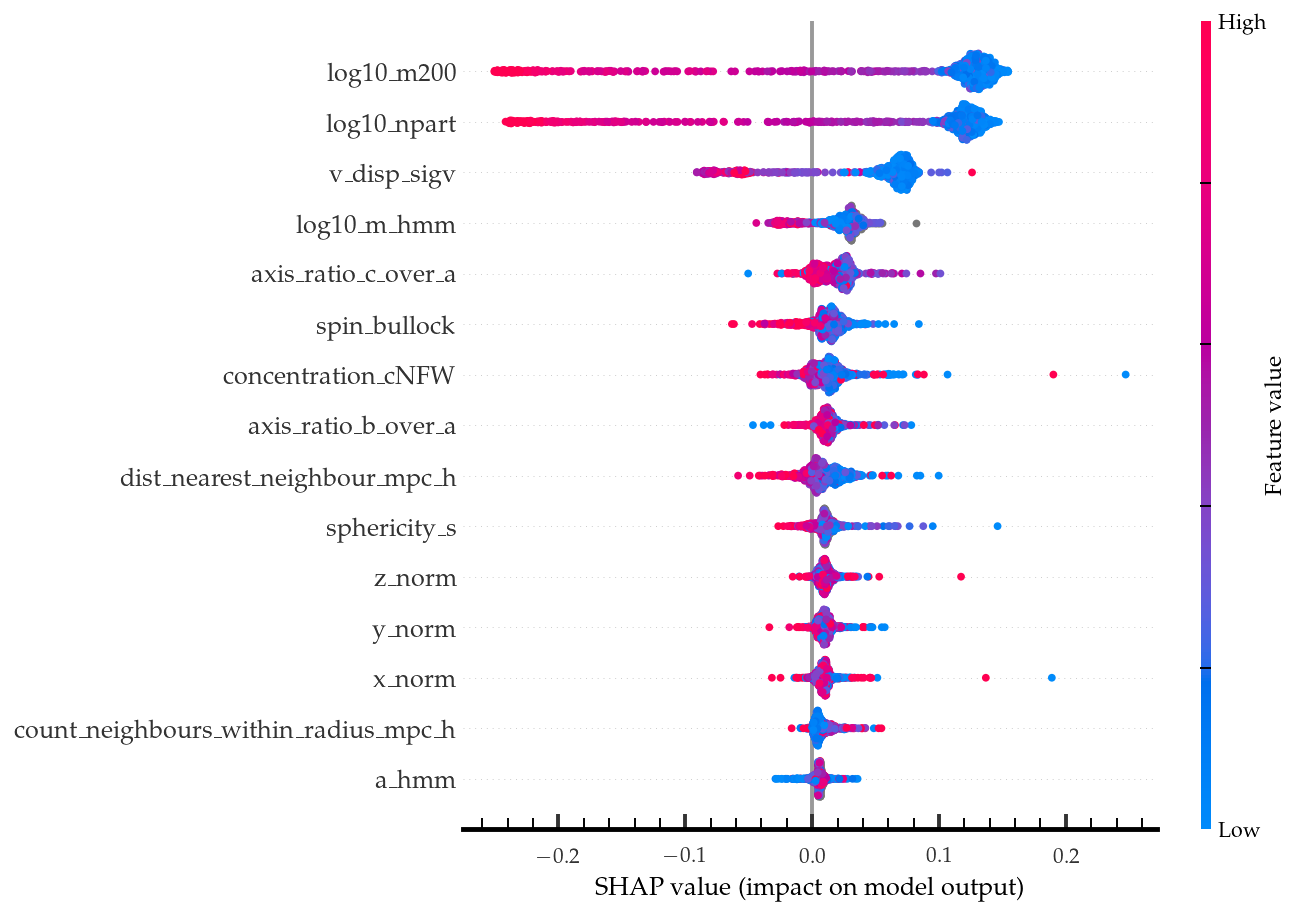

In [5]:
sv        = shap_values[("rf", "within_sim")]
X_display = X_shap_data["within_sim"]

# Wrap in an Explanation object so shap.plots.beeswarm receives the
# feature values needed for colouring (data) alongside the SHAP values.
explanation = shap.Explanation(
    values=sv,
    data=X_display,
    feature_names=FEATURE_COLS,
)
shap.plots.beeswarm(explanation, max_display=15, show=False)
fig = plt.gcf()
fig.savefig(FIGURES_DIR / "06_shap_beeswarm.png", dpi=200, bbox_inches="tight")


## 2. Feature importance across models (within-simulation)

Mean absolute SHAP value per feature, normalised to sum to 1 within each model. We normalise to allow cross-model comparison despite the models operating on different output scales (log-odds for LR, probability for RF/GBM, logit for MLP).

Features are ordered by RF importance (left = most important for RF). An agreement across models on broad ranking patterns increases the confidence that a feature is informative, although the exact rank positions should be interpreted with some model dependence.

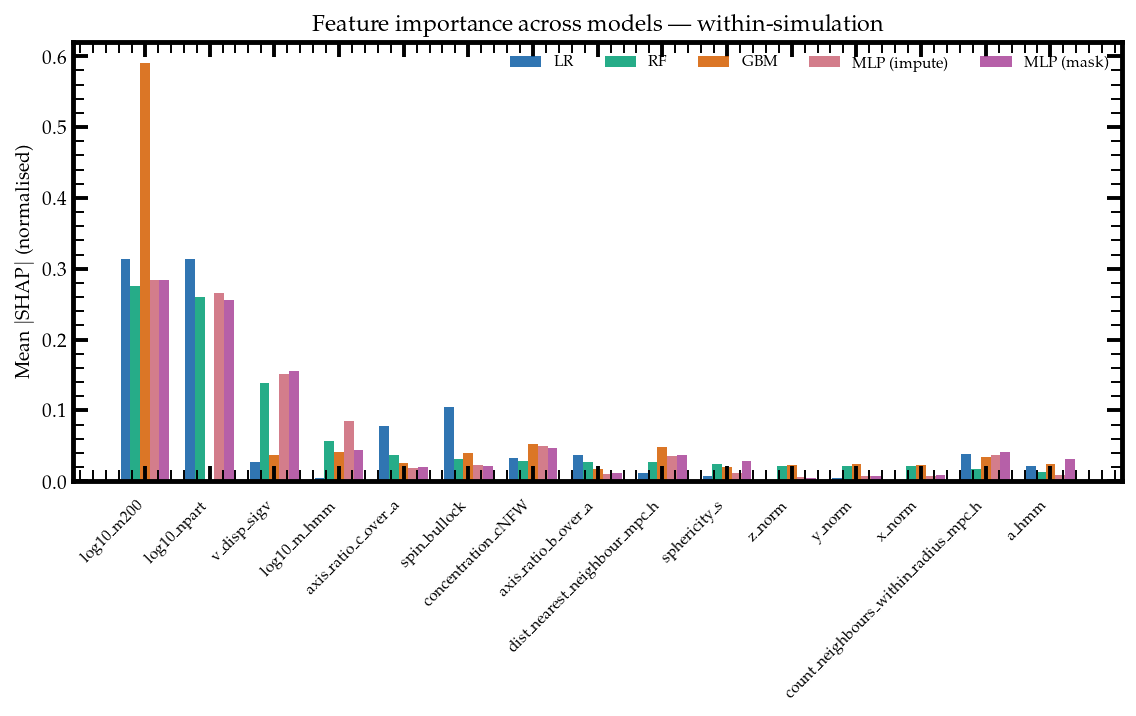

In [11]:
# Compute normalised mean |SHAP| for each model within within_sim.
mean_abs: dict = {}
for model_name in SKL_SHAP_MODELS + MLP_NAMES:
    key = (model_name, "within_sim")
    if key not in shap_values:
        continue
    sv = shap_values[key]
    # For mlp_mask (18 dims), restrict to the 15 feature columns.
    sv_15  = sv[:, :len(FEATURE_COLS)]
    imp    = np.abs(sv_15).mean(axis=0)
    mean_abs[model_name] = imp / imp.sum()

# Sort features by RF importance descending.
if "rf" in mean_abs:
    sort_idx = np.argsort(mean_abs["rf"])[::-1]
else:
    sort_idx = np.arange(len(FEATURE_COLS))
sorted_feats = [FEATURE_COLS[i] for i in sort_idx]
n_feats  = len(sorted_feats)
n_models = len(mean_abs)

bar_w   = 0.15
x       = np.arange(n_feats)
offsets = (np.arange(n_models) - (n_models - 1) / 2) * bar_w

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

for i, (model_name, color) in enumerate(zip(mean_abs, PALETTE)):
    imp_sorted = np.ravel(mean_abs[model_name][sort_idx])
    _ = ax.bar(
        x + offsets[i], imp_sorted,
        width=bar_w, label=MODEL_LABELS[model_name],
        color=color, alpha=0.85, linewidth=0,
    )

_ = ax.set_xticks(x)
_ = ax.set_xticklabels(sorted_feats, rotation=45, ha="right", fontsize=8)
_ = ax.set_ylabel(r"Mean $\vert$SHAP$\vert$ (normalised)")
_ = ax.set_title("Feature importance across models — within-simulation")
_ = ax.legend(fontsize=8, ncol=n_models)

**Note on `log10_m200` and `log10_npart`.**
In a uniform dark-matter-only simulation at fixed mass resolution, halo mass is particle count times particle mass (`1e7 M_sun/h` for the 512^3 runs), so `log10_m200 = log10_npart + constant`. In this setup, the two features are effectively perfectly collinear.

GBM (sequential boosting) can allocate most splits to whichever feature wins first, here `log10_m200`, leaving `log10_npart` near zero in SHAP importance.

RF can distribute importance across both because it subsamples features at each split, and LR/MLP can spread weight across collinear inputs.

The combined mass/particle-count signal is the same, but what differs across models is how importance is allocated between the two collinear columns. Dropping one of the pair would likely leave qualitative conclusions unchanged.

## 3. Feature importance across splits (RF)

How does the RF's feature importance change as the test distribution shifts?

A stable ranking across splits is consistent with features carrying information that transfers beyond the training distribution. A collapsing rank, especially for sphericity, would suggest weaker transfer of the paper's empirical-cut intuition in the regimes where the ML classifier is intended to improve robustness.

Values are normalised mean |SHAP| per split (same normalisation as Section 2).

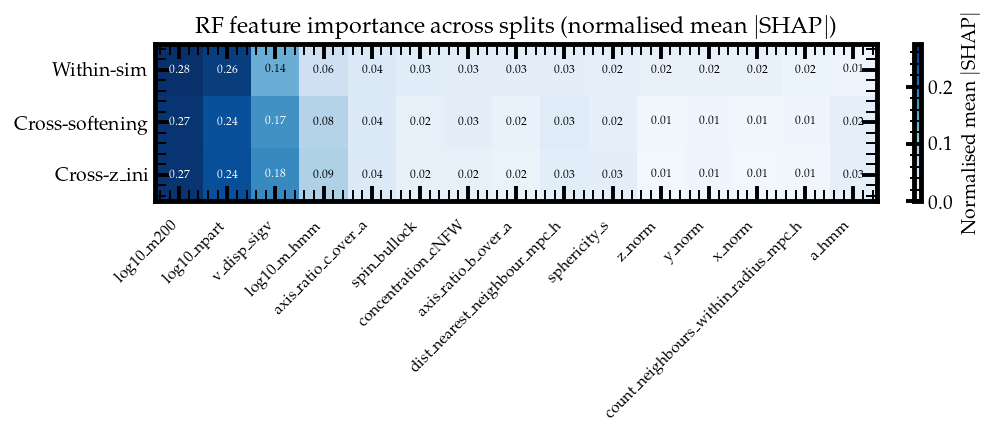

In [14]:
rf_imp: dict = {}
for split in SPLITS:
    key = ("rf", split)
    if key not in shap_values:
        continue
    sv  = shap_values[key]
    imp = np.abs(sv).mean(axis=0)
    rf_imp[split] = imp / imp.sum()

available_splits = [s for s in SPLITS if s in rf_imp]

# Sort features by within_sim importance.
if "within_sim" in rf_imp:
    sort_idx_rf = np.argsort(rf_imp["within_sim"])[::-1]
else:
    sort_idx_rf = sort_idx  # Fall back to cross-model ordering from Section 2.
sorted_feats_rf = [FEATURE_COLS[i] for i in sort_idx_rf]

# Build heatmap array: rows = splits, cols = features (sorted by within_sim).
hm_data = np.array([rf_imp[s][sort_idx_rf] for s in available_splits])

fig, ax = plt.subplots(figsize=(7, 3), constrained_layout=True)
im = ax.imshow(hm_data, aspect="auto", cmap="Blues", vmin=0)

_ = ax.set_xticks(np.arange(n_feats))
_ = ax.set_xticklabels(sorted_feats_rf, rotation=45, ha="right", fontsize=8)
_ = ax.set_yticks(np.arange(len(available_splits)))
_ = ax.set_yticklabels([SPLIT_LABELS[s] for s in available_splits])
_ = ax.set_title(r"RF feature importance across splits (normalised mean $\vert$SHAP$\vert$)")
_ = plt.colorbar(im, ax=ax, label=r"Normalised mean $\vert$SHAP$\vert$")

for i in range(hm_data.shape[0]):
    for j in range(hm_data.shape[1]):
        text_color = "white" if hm_data[i, j] > 0.15 else "black"
        _ = ax.text(
            j, i, f"{hm_data[i, j]:.2f}",
            ha="center", va="center", fontsize=6, color=text_color,
        )

## 4. Dependence plots for key features

Each panel shows one feature's SHAP value vs. its raw value across the within-sim test set. Points are coloured by the most important other feature (by RF importance) to reveal interaction effects.

The four features shown are the top four by RF importance in within-simulation. These panels expose the *direction* of each effect (does high sphericity push toward genuine or spurious?) and whether there is a threshold or continuous relationship.

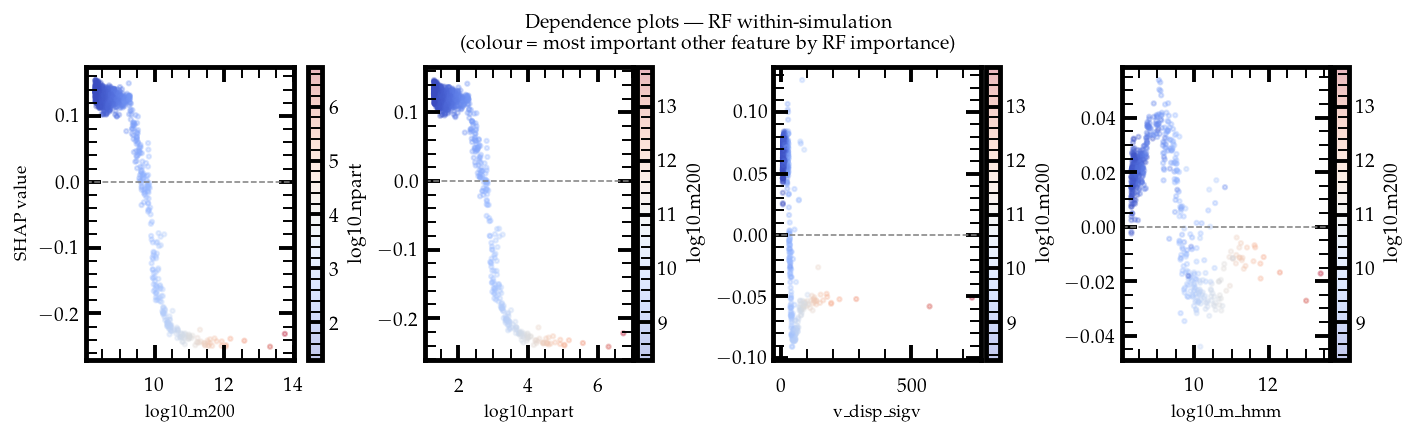

In [23]:
sv        = shap_values[("rf", "within_sim")]
X_display = X_shap_data["within_sim"]

# Top 4 features by RF within_sim importance.
top4_idx   = sort_idx_rf[:4]
top4_names = [FEATURE_COLS[i] for i in top4_idx]

# Colour each panel by whichever top-4 feature is NOT on the x-axis
# and has the highest importance among the remaining three.
fig, axes = plt.subplots(1, 4, figsize=(10, 3), constrained_layout=True)

for ax, feat_idx, feat_name in zip(axes, top4_idx, top4_names):
    feat_vals  = X_display[:, feat_idx]
    shap_feat  = sv[:, feat_idx]
    # Colour by the highest-importance feature that isn't this one.
    color_idx  = next(i for i in sort_idx_rf if i != feat_idx)
    color_vals = X_display[:, color_idx]

    sc = ax.scatter(
        feat_vals, shap_feat,
        c=color_vals, cmap="coolwarm",
        alpha=0.3, s=5, rasterized=True,
    )
    _ = ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    _ = ax.set_xlabel(feat_name, fontsize=9)
    _ = ax.set_ylabel("SHAP value" if ax is axes[0] else "", fontsize=9)
    _ = plt.colorbar(sc, ax=ax, label=FEATURE_COLS[color_idx], pad=0.02)

_ = fig.suptitle(
    "Dependence plots — RF within-simulation\n"
    "(colour = most important other feature by RF importance)",
    fontsize=10,
)

## 5. Host vs. subhalo breakdown

Subhaloes orbit inside a host halo and are more susceptible to tidal stripping, which can reshape their morphology and kinematics in ways unrelated to artificial fragmentation. 

If the model relies on different features for hosts vs. subhaloes, that tells us something about where the spurious signal actually lives.

The difference plot (bottom) shows host importance minus subhalo importance. Here, positive (orange) means the feature matters more for hosts.

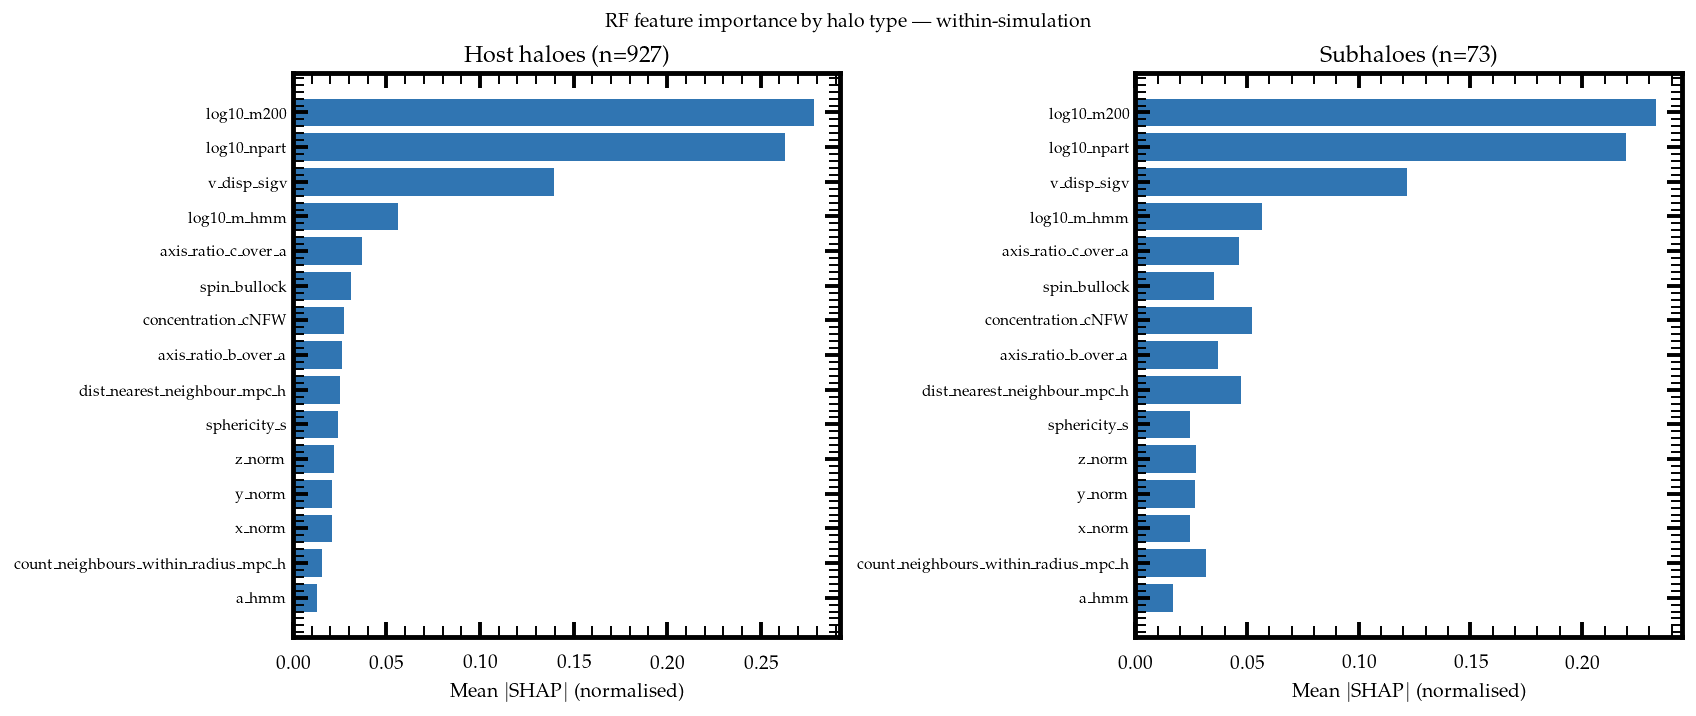

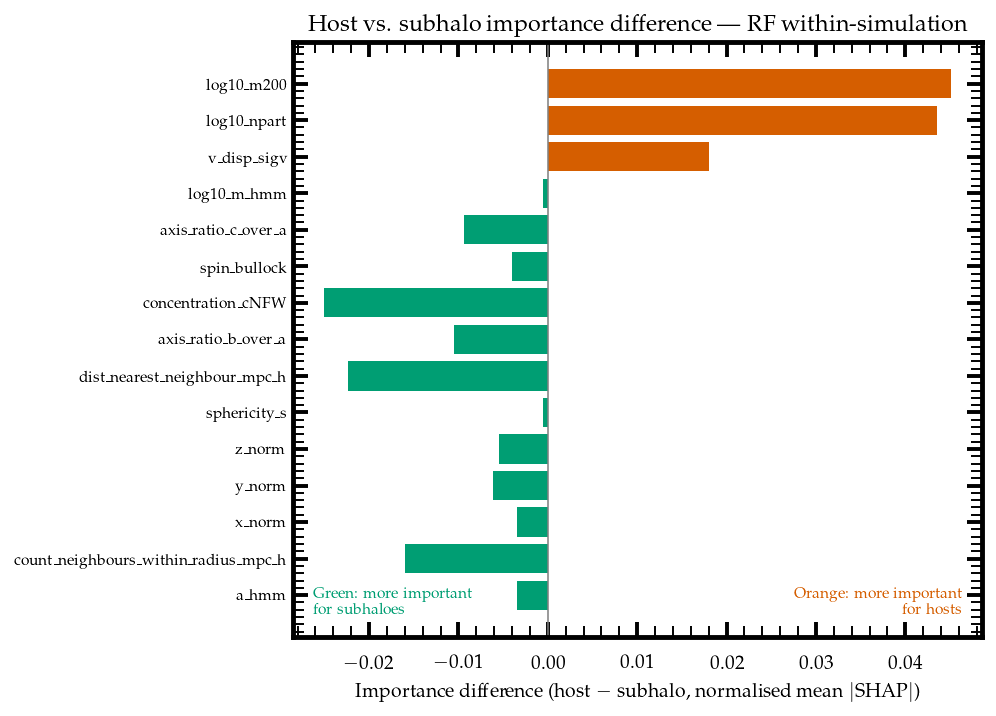

In [25]:
sv_ws   = shap_values.get(("rf", "within_sim"))
is_host = is_host_shap["within_sim"]

if sv_ws is not None and is_host.sum() > 0 and (~is_host).sum() > 0:
    imp_host = np.abs(sv_ws[is_host]).mean(axis=0)
    imp_sub  = np.abs(sv_ws[~is_host]).mean(axis=0)
    imp_host_norm = imp_host / imp_host.sum()
    imp_sub_norm  = imp_sub  / imp_sub.sum()

    # Reuse RF within_sim sort order so axes are consistent with Sections 2-4.
    feats_rev = sorted_feats_rf[::-1]  # Bottom-to-top for horizontal bars.
    idx_rev   = sort_idx_rf[::-1]

    # --- Side-by-side bars ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    for ax, imp_norm, title in zip(
        axes,
        [imp_host_norm, imp_sub_norm],
        [f"Host haloes (n={is_host.sum():,})", f"Subhaloes (n={(~is_host).sum():,})"],
    ):
        _ = ax.barh(
            np.arange(n_feats), imp_norm[idx_rev],
            color="#0C5DA5", alpha=0.85, linewidth=0,
        )
        _ = ax.set_yticks(np.arange(n_feats))
        _ = ax.set_yticklabels(feats_rev, fontsize=8)
        _ = ax.set_xlabel(r"Mean $\vert$SHAP$\vert$ (normalised)")
        _ = ax.set_title(title)

    _ = fig.suptitle(
        "RF feature importance by halo type — within-simulation", fontsize=10
    )

    # --- Difference plot ---
    diff = imp_host_norm[idx_rev] - imp_sub_norm[idx_rev]
    bar_colors = ["#D55E00" if d > 0 else "#009E73" for d in diff]

    fig2, ax2 = plt.subplots(figsize=(7, 5), constrained_layout=True)
    _ = ax2.barh(np.arange(n_feats), diff, color=bar_colors, linewidth=0)
    _ = ax2.set_yticks(np.arange(n_feats))
    _ = ax2.set_yticklabels(feats_rev, fontsize=8)
    _ = ax2.axvline(0, color="grey", linewidth=0.8)
    _ = ax2.set_xlabel(
        r"Importance difference (host $-$ subhalo, normalised mean $\vert$SHAP$\vert$)"
    )
    _ = ax2.set_title(
        "Host vs. subhalo importance difference — RF within-simulation"
    )
    _ = ax2.text(
        0.97, 0.03, "Orange: more important\nfor hosts",
        transform=ax2.transAxes, ha="right", va="bottom",
        fontsize=8, color="#D55E00",
    )
    _ = ax2.text(
        0.03, 0.03, "Green: more important\nfor subhaloes",
        transform=ax2.transAxes, ha="left", va="bottom",
        fontsize=8, color="#009E73",
    )

### Supplementary: missingness indicator SHAP values (mlp_mask)

`mlp_mask` receives three binary flags indicating whether `sphericity_s`, `log10_m_hmm`, and `a_hmm` are missing. The SHAP values of these indicators estimate how much the model uses *knowing that a feature is absent*, above and beyond the feature value when it is present.

If indicator SHAP values are non-trivial (comparable in magnitude to feature SHAP values), this suggests haloes without protohalo records are statistically distinct in ways the model can exploit.

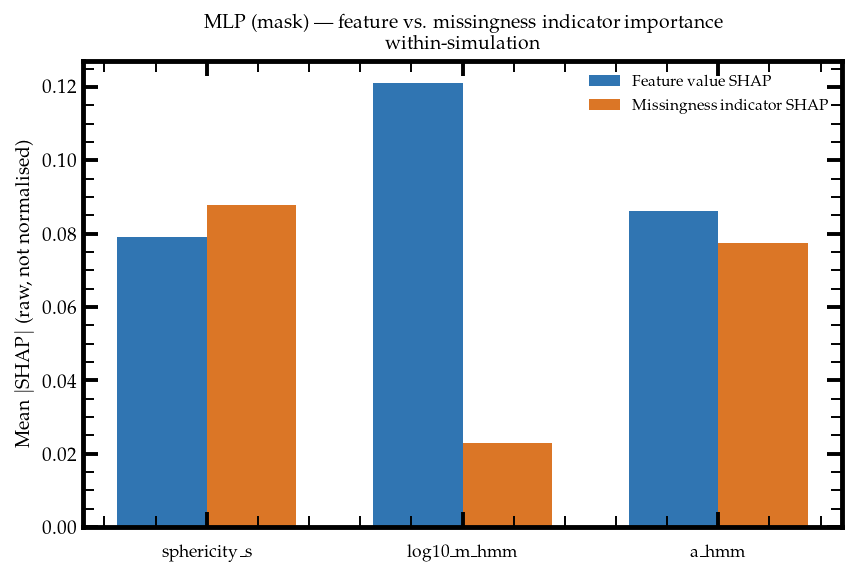

In [10]:
key_mask = ("mlp_mask", "within_sim")
if key_mask in shap_values:
    sv_mask = shap_values[key_mask]  # shape (n_samples, 18)
    sv_inds = sv_mask[:, len(FEATURE_COLS):]  # Last 3 columns are indicators.

    # Compare mean |SHAP| of the three indicator columns to their
    # corresponding feature columns.
    feature_imp    = np.abs(sv_mask[:, NULLABLE_IDX]).mean(axis=0)
    indicator_imp  = np.abs(sv_inds).mean(axis=0)

    feat_labels = [FEATURE_COLS[i] for i in NULLABLE_IDX]
    x_ind = np.arange(len(NULLABLE_FEATURES))
    bar_w_ind = 0.35

    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    _ = ax.bar(
        x_ind - bar_w_ind / 2, feature_imp,
        width=bar_w_ind, label="Feature value SHAP", color="#0C5DA5", alpha=0.85, linewidth=0,
    )
    _ = ax.bar(
        x_ind + bar_w_ind / 2, indicator_imp,
        width=bar_w_ind, label="Missingness indicator SHAP", color="#D55E00", alpha=0.85, linewidth=0,
    )
    _ = ax.set_xticks(x_ind)
    _ = ax.set_xticklabels(feat_labels, fontsize=9)
    _ = ax.set_ylabel(r"Mean $\vert$SHAP$\vert$ (raw, not normalised)")
    _ = ax.set_title(
        "MLP (mask) — feature vs. missingness indicator importance\n"
        "within-simulation",
        fontsize=10,
    )
    _ = ax.legend(fontsize=8)

## 6. Scientific interpretation

### What the feature-importance analysis found

`log10_m200` (with collinear `log10_npart`) is the dominant signal across models. `v_disp_sigv` is typically among the next most important features, while sphericity ranks lower.

### Mass dominance: expected pattern and label implications

Mass dominance is expected to some degree. Spurious haloes are associated with artificial fragmentation near suppressed WDM mass scales, so low mass is an informative regime. In addition, the `is_spurious_cdm_match` label can inherit mass dependence through counterpart availability below the free-streaming cutoff.

This implies that SHAP recovering mass as the primary signal is partly aligned with both underlying physics and label construction. A cautious interpretation is that the classifier relies strongly on mass-scale separation, with additional refinement from other features.

### Velocity dispersion as a secondary signal

`v_disp_sigv` ranking highly and relatively consistently across LR, RF, GBM, and both MLP variants is the key non-trivial result. This pattern is consistent with velocity dispersion carrying information beyond mass alone. A plausible physical interpretation is that artificial-fragmentation haloes have systematically different internal kinematics than genuine haloes at similar mass.

### Why sphericity can rank low

Sphericity (`sphericity_s`) sits near the bottom of the SHAP ranking despite being central to the paper's empirical diagnostic. Two explanations are consistent with this outcome:

1. The CDM-match label is not defined by sphericity, so once mass-linked structure is captured, sphericity may contribute limited incremental signal.

2. A substantial fraction of haloes lack protohalo records (and therefore `sphericity_s`), which can dilute measured importance for sphericity relative to always-available features.

Both effects may contribute. The Section 5 indicator analysis is relevant: if the missingness indicator for `sphericity_s` carries non-trivial SHAP weight, the model is using missingness structure as additional information.

### What this analysis does not resolve

The cross-split heatmap (Section 3) is most relevant for transferability:

- If `v_disp_sigv` remains stable across `within_sim`, `cross_softening`, and `cross_z_ini` while mass remains dominant, that supports kinematics as a robust secondary discriminant.
- If rankings shift on `cross_z_ini` (where the paper's empirical-cut transfer is weaker), that helps identify which features transfer best across initial-redshift changes.

Section 7 extends this by examining where cross-split errors occur in feature space, helping distinguish whether residual transfer error is primarily mass-scale or dynamical-state related.